## Project 3: Monte Carlo Option Pricing
**Simulating thousands of stock price paths under Geometric Brownian Motion to price options without closed-form formulas.**

In [1]:
import numpy as np
import scipy.stats as si
import matplotlib.pyplot as plt
!pip install yfinance --quiet
import yfinance as yf

##  Geometric Brownian Motion (GBM)
Stock price follows: `dS = μS dt + σS dW`  
Discretized as: `S(t+dt) = S(t) · exp((r - σ²/2)dt + σ√dt · Z)` where Z ~ N(0,1)

In [2]:
def simulate_gbm_paths(S0, r, sigma, T, n_steps, n_paths, seed=42):
    """
    Simulate stock price paths under GBM.
    Returns array of shape (n_steps+1, n_paths).
    """
    np.random.seed(seed)
    dt = T / n_steps
    Z  = np.random.standard_normal((n_steps, n_paths))
    
    increments = np.exp((r - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z)
    
    paths = np.ones((n_steps + 1, n_paths)) * S0
    for t in range(1, n_steps + 1):
        paths[t] = paths[t-1] * increments[t-1]
    
    return paths

print("✅ GBM simulation function defined.")

✅ GBM simulation function defined.


In [3]:
ticker = "AAPL"
data = yf.Ticker(ticker)
S0 = data.history(period="1d")['Close'].iloc[0]
hist = data.history(period="1y")['Close']
sigma = np.std(hist.pct_change().dropna()) * np.sqrt(252)

K = round(S0)
T = 30 / 365
r = 0.05
n_steps = 30
n_paths = 10_000

print(f"{ticker} | S0=${S0:.2f} | K=${K} | σ={sigma:.2%} | T=30d")

AAPL | S0=$260.81 | K=$261 | σ=31.80% | T=30d


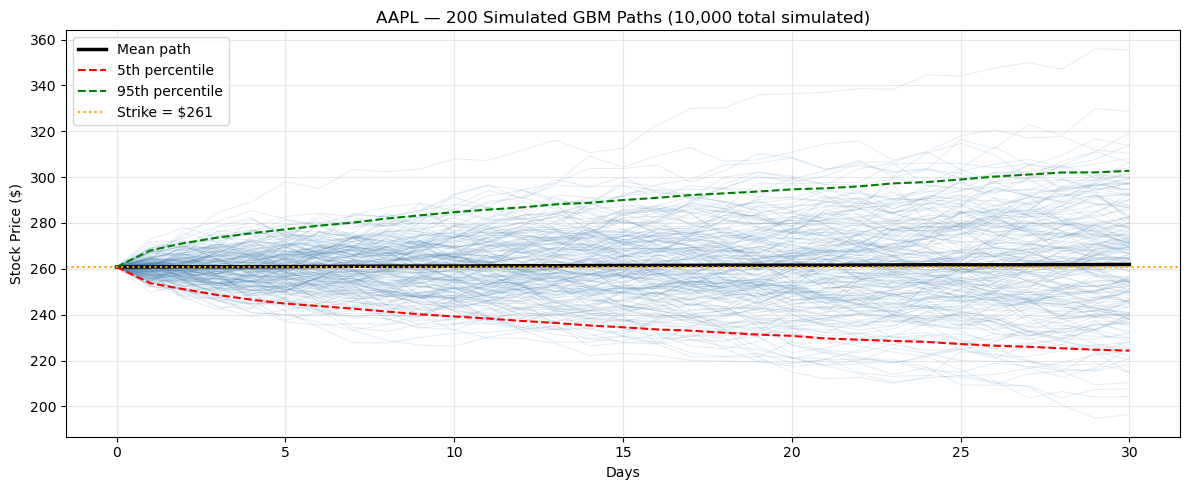

Final price distribution: Mean=$261.91 | Std=$23.96


In [4]:
paths = simulate_gbm_paths(S0, r, sigma, T, n_steps, n_paths)
time_axis = np.linspace(0, T * 365, n_steps + 1)

plt.figure(figsize=(12, 5))
plt.plot(time_axis, paths[:, :200], alpha=0.15, lw=0.7, color='steelblue')  # 200 sample paths
plt.plot(time_axis, np.mean(paths, axis=1), 'k-', lw=2.5, label='Mean path')
plt.plot(time_axis, np.percentile(paths, 5,  axis=1), 'r--', lw=1.5, label='5th percentile')
plt.plot(time_axis, np.percentile(paths, 95, axis=1), 'g--', lw=1.5, label='95th percentile')
plt.axhline(K, color='orange', linestyle=':', lw=1.5, label=f'Strike = ${K}')
plt.xlabel('Days'); plt.ylabel('Stock Price ($)')
plt.title(f'{ticker} — 200 Simulated GBM Paths ({n_paths:,} total simulated)')
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

print(f"Final price distribution: Mean=${np.mean(paths[-1]):.2f} | Std=${np.std(paths[-1]):.2f}")

In [5]:
def mc_european_call(S0, K, T, r, sigma, n_paths=100_000, seed=42):
    """
    Price a European Call via Monte Carlo.
    Payoff = max(S_T - K, 0), discounted at risk-free rate.
    """
    np.random.seed(seed)
    Z = np.random.standard_normal(n_paths)
    S_T = S0 * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * Z)
    payoffs = np.maximum(S_T - K, 0)
    price = np.exp(-r * T) * np.mean(payoffs)
    stderr = np.exp(-r * T) * np.std(payoffs) / np.sqrt(n_paths)
    return price, stderr

def mc_european_put(S0, K, T, r, sigma, n_paths=100_000, seed=42):
    """Price a European Put via Monte Carlo."""
    np.random.seed(seed)
    Z = np.random.standard_normal(n_paths)
    S_T = S0 * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * Z)
    payoffs = np.maximum(K - S_T, 0)
    price = np.exp(-r * T) * np.mean(payoffs)
    stderr = np.exp(-r * T) * np.std(payoffs) / np.sqrt(n_paths)
    return price, stderr

def bs_call(S, K, T, r, sigma):
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    return S*si.norm.cdf(d1) - K*np.exp(-r*T)*si.norm.cdf(d2)

def bs_put(S, K, T, r, sigma):
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    return K*np.exp(-r*T)*si.norm.cdf(-d2) - S*si.norm.cdf(-d1)

mc_call, mc_call_se = mc_european_call(S0, K, T, r, sigma)
mc_put,  mc_put_se  = mc_european_put(S0, K, T, r, sigma)
bs_c = bs_call(S0, K, T, r, sigma)
bs_p = bs_put(S0, K, T, r, sigma)

print(f"{'':20} {'Call':>12} {'Put':>12}")
print("=" * 46)
print(f"{'Black-Scholes':20} {'$'+f'{bs_c:.4f}':>12} {'$'+f'{bs_p:.4f}':>12}")
print(f"{'Monte Carlo':20} {'$'+f'{mc_call:.4f}':>12} {'$'+f'{mc_put:.4f}':>12}")
print(f"{'MC Std Error':20} {'±$'+f'{mc_call_se:.4f}':>12} {'±$'+f'{mc_put_se:.4f}':>12}")
print(f"{'Difference':20} {'$'+f'{abs(mc_call-bs_c):.4f}':>12} {'$'+f'{abs(mc_put-bs_p):.4f}':>12}")

                             Call          Put
Black-Scholes             $9.9147      $9.0343
Monte Carlo               $9.9382      $9.0329
MC Std Error             ±$0.0473     ±$0.0407
Difference                $0.0235      $0.0014


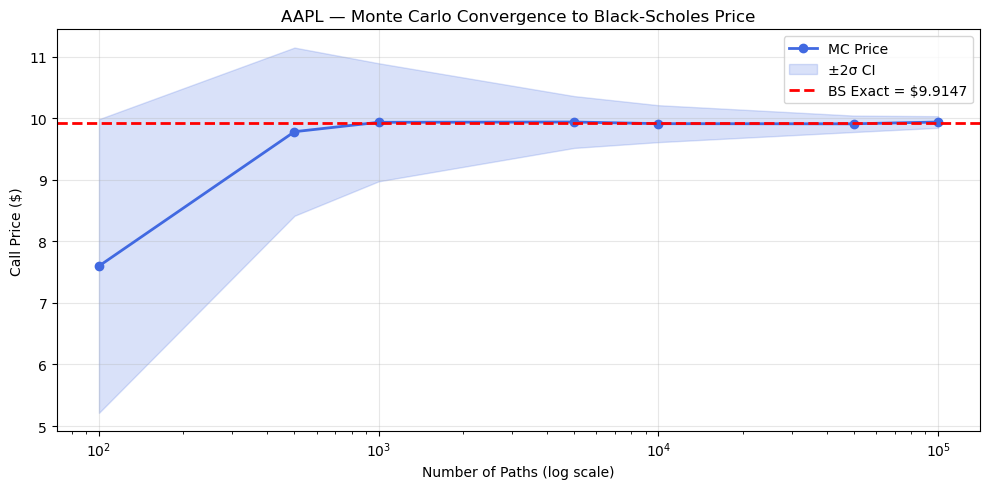

In [6]:
path_counts = [100, 500, 1_000, 5_000, 10_000, 50_000, 100_000]
mc_prices   = [mc_european_call(S0, K, T, r, sigma, n)[0] for n in path_counts]
mc_errors   = [mc_european_call(S0, K, T, r, sigma, n)[1] for n in path_counts]

plt.figure(figsize=(10, 5))
plt.semilogx(path_counts, mc_prices, 'o-', color='royalblue', lw=2, label='MC Price')
plt.fill_between(path_counts,
                 [p - 2*e for p,e in zip(mc_prices, mc_errors)],
                 [p + 2*e for p,e in zip(mc_prices, mc_errors)],
                 alpha=0.2, color='royalblue', label='±2σ CI')
plt.axhline(bs_c, color='red', linestyle='--', lw=2, label=f'BS Exact = ${bs_c:.4f}')
plt.xlabel('Number of Paths (log scale)')
plt.ylabel('Call Price ($)')
plt.title(f'{ticker} — Monte Carlo Convergence to Black-Scholes Price')
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

In [7]:
def mc_asian_call(S0, K, T, r, sigma, n_steps=252, n_paths=50_000, seed=42):
    """
    Asian (Average Price) Call Option.
    Payoff = max(mean(S_path) - K, 0)
    Cheaper than European — averaging reduces vol exposure.
    """
    np.random.seed(seed)
    dt = T / n_steps
    Z  = np.random.standard_normal((n_steps, n_paths))
    paths = np.ones((n_steps + 1, n_paths)) * S0
    for t in range(1, n_steps + 1):
        paths[t] = paths[t-1] * np.exp((r - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*Z[t-1])
    avg_price = np.mean(paths, axis=0)
    payoffs   = np.maximum(avg_price - K, 0)
    return np.exp(-r * T) * np.mean(payoffs)

def mc_barrier_call(S0, K, T, r, sigma, barrier, n_steps=252, n_paths=50_000, seed=42):
    """
    Down-and-Out Barrier Call Option.
    Expires WORTHLESS if stock touches the barrier anytime during T.
    Cheaper than vanilla — you take on knock-out risk.
    """
    np.random.seed(seed)
    dt = T / n_steps
    Z  = np.random.standard_normal((n_steps, n_paths))
    paths = np.ones((n_steps + 1, n_paths)) * S0
    for t in range(1, n_steps + 1):
        paths[t] = paths[t-1] * np.exp((r - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*Z[t-1])
    alive   = np.all(paths >= barrier, axis=0) 
    payoffs = np.maximum(paths[-1] - K, 0) * alive
    return np.exp(-r * T) * np.mean(payoffs)

barrier = S0 * 0.85  
asian_price   = mc_asian_call(S0, K, T, r, sigma)
barrier_price = mc_barrier_call(S0, K, T, r, sigma, barrier)

print(f"Option Comparison (K=${K}, T=30d):")
print(f"  European Call (BS exact):       ${bs_c:.4f}")
print(f"  Asian (Average Price) Call MC:  ${asian_price:.4f}   (cheaper — averaging dampens vol)")
print(f"  Barrier Call MC (B=${barrier:.0f}):  ${barrier_price:.4f}   (cheapest — knock-out risk)")

Option Comparison (K=$261, T=30d):
  European Call (BS exact):       $9.9147
  Asian (Average Price) Call MC:  $5.5951   (cheaper — averaging dampens vol)
  Barrier Call MC (B=$222):  $9.8813   (cheapest — knock-out risk)


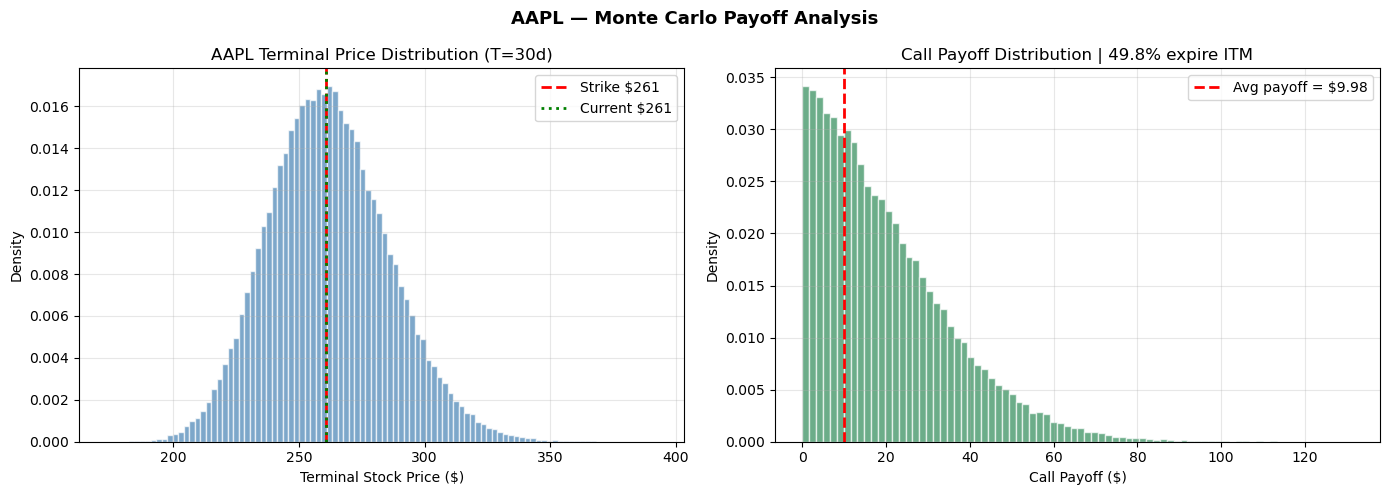


Summary:
  Paths expiring ITM: 49.8%
  Expected payoff:    $9.9791
  Discounted price:   $9.9382
  BS exact price:     $9.9147


In [8]:
np.random.seed(42)
Z = np.random.standard_normal(100_000)
S_T = S0 * np.exp((r - 0.5*sigma**2)*T + sigma*np.sqrt(T)*Z)
call_payoffs = np.maximum(S_T - K, 0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Terminal stock price distribution
axes[0].hist(S_T, bins=100, color='steelblue', alpha=0.7, edgecolor='white', density=True)
axes[0].axvline(K,  color='red',   linestyle='--', lw=2, label=f'Strike ${K}')
axes[0].axvline(S0, color='green', linestyle=':',  lw=2, label=f'Current ${S0:.0f}')
axes[0].set_xlabel('Terminal Stock Price ($)')
axes[0].set_ylabel('Density')
axes[0].set_title(f'{ticker} Terminal Price Distribution (T=30d)')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Call payoff distribution
positive = call_payoffs[call_payoffs > 0]
axes[1].hist(positive, bins=80, color='seagreen', alpha=0.7, edgecolor='white', density=True)
axes[1].axvline(np.mean(call_payoffs), color='red', linestyle='--', lw=2,
                label=f'Avg payoff = ${np.mean(call_payoffs):.2f}')
pct_itm = 100 * np.mean(call_payoffs > 0)
axes[1].set_xlabel('Call Payoff ($)')
axes[1].set_ylabel('Density')
axes[1].set_title(f'Call Payoff Distribution | {pct_itm:.1f}% expire ITM')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle(f'{ticker} — Monte Carlo Payoff Analysis', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

print(f"\nSummary:")
print(f"  Paths expiring ITM: {pct_itm:.1f}%")
print(f"  Expected payoff:    ${np.mean(call_payoffs):.4f}")
print(f"  Discounted price:   ${np.exp(-r*T)*np.mean(call_payoffs):.4f}")
print(f"  BS exact price:     ${bs_c:.4f}")